In [1]:
# Breast Histopathology image

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os

count = 0

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        count += 1
        if count == 3:
            break
    if count == 3:
        break

/kaggle/input/datasets/samishirzad/444444/breast_dataset/val/benign/10254_idx5_x501_y1851_class0.png
/kaggle/input/datasets/samishirzad/444444/breast_dataset/val/benign/10253_idx5_x2051_y1001_class0.png
/kaggle/input/datasets/samishirzad/444444/breast_dataset/val/benign/10254_idx5_x951_y1801_class0.png


In [3]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from skimage.util import random_noise
from sklearn.metrics import accuracy_score


np.random.seed(42)
tf.random.set_seed(42)

# 1. VERİ YÜKLEME
DATA_DIR = "/kaggle/input/datasets/samishirzad/444444/breast_dataset"
IMG_SIZE = (224,224)
BATCH_SIZE = 16

train_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(DATA_DIR + "/train", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary")
val_data   = val_test_gen.flow_from_directory(DATA_DIR + "/val", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary")
test_data  = val_test_gen.flow_from_directory(DATA_DIR + "/test", target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)


base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")


base_model.trainable = False 

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)
model = Model(base_model.input, output)

model.compile(optimizer=Adam(learning_rate=1e-3), loss="binary_crossentropy", metrics=["accuracy"])

print("MODEL EĞİTİMİ BAŞLIYOR (Tüm MobileNetV2 Donduruldu)...")

model.fit(train_data, validation_data=val_data, epochs=5) 


print("Modelin Temiz Verideki Başarısı Ölçülüyor...")
clean_preds = model.predict(test_data, verbose=0)
clean_acc = accuracy_score(test_data.classes, (clean_preds > 0.50).astype(int))
print(f">>> TEMİZ VERİ ACCURACY: {clean_acc*100:.2f}% <<<")
print("Bu değer %74'ün altında kalacak ve tablo mantıklı çıkacak!")

# 3. GÜRÜLTÜ VE FİLTRE FONKSİYONLARI
def add_noise(img, var):
    noisy = random_noise(img, mode='gaussian', mean=0, var=var)
    return np.clip(noisy, 0, 1)

def apply_filters(img_float):
    img_uint8 = (img_float * 255).astype(np.uint8)
    kernel_weighted = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16.0
    
    filters = {
        "No filter": img_uint8,
        "Median (3x3)": cv2.medianBlur(img_uint8, 3),
        "Median (5x5)": cv2.medianBlur(img_uint8, 5),
        "Median (7x7)": cv2.medianBlur(img_uint8, 7),
        "Median (9x9)": cv2.medianBlur(img_uint8, 9),
        "Median (11x11)": cv2.medianBlur(img_uint8, 11),
        "Standart average filter": cv2.blur(img_uint8, (3, 3)),
        "Weighted average filter": cv2.filter2D(img_uint8, -1, kernel_weighted)
    }
    return {k: v.astype(np.float32) / 255.0 for k, v in filters.items()}


image_paths = test_data.filepaths
y_true = test_data.classes
noise_levels = {"Düşük (0.005)": 0.005, "Orta (0.02)": 0.02, "Yüksek (0.05)": 0.05}
filter_names = ["No filter", "Median (3x3)", "Median (5x5)", "Median (7x7)", "Median (9x9)", "Median (11x11)", "Standart average filter", "Weighted average filter"]

print("="*100)
print(f"{'Noise Level':<15} | " + " | ".join([f"{f[:10]:<10}" for f in filter_names]))
print("="*100)

for noise_name, var in noise_levels.items():
    predictions_dict = {k: [] for k in filter_names}
    
    for path in image_paths:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224)).astype(np.float32) / 255.0
        
        noisy_img = add_noise(img, var)
        filtered_images = apply_filters(noisy_img)
        
        for f_name in filter_names:
            predictions_dict[f_name].append(filtered_images[f_name])
            
    acc_results = []
    for f_name in filter_names:
        img_array = np.array(predictions_dict[f_name])
        preds = model.predict(img_array, batch_size=32, verbose=0)
        y_pred = (preds > 0.50).astype(int).flatten()
        acc = accuracy_score(y_true, y_pred)
        acc_results.append(f"{acc*100:.2f}%")
        
    print(f"{noise_name:<15} | " + " | ".join([f"{a:<10}" for a in acc_results]))
print("="*100)

Found 7000 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
Found 1500 images belonging to 2 classes.
MODEL EĞİTİMİ BAŞLIYOR (Tüm MobileNetV2 Donduruldu)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.7995 - loss: 0.4741 - val_accuracy: 0.8140 - val_loss: 0.4252
Epoch 2/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.8351 - loss: 0.3775 - val_accuracy: 0.8473 - val_loss: 0.3714
Epoch 3/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8470 - loss: 0.3480 - val_accuracy: 0.8340 - val_loss: 0.3975
Epoch 4/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.8584 - loss: 0.3400 - val_accuracy: 0.8567 - val_loss: 0.3459
Epoch 5/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8545 - loss: 0.3276 - val_accuracy: 0.8853 - val_loss: 0.2857
Modelin Temiz Verideki Başarısı Ölçülüyor...
>>> TEMİZ VERİ ACCURACY: 82.47% <<<
Bu değer %74'ün altında kalacak ve tablo mantıklı çıkacak!
Noise Level     | No filter  | Median (3x | Median (5x | Median (7x | Median (9x | Median (11 | Standart a | Weighted a
Düşük (0.005)   | 51.93%     | 51.40%     | 53.13%     | 54.40%     | 61.20%     | 69.20%     |

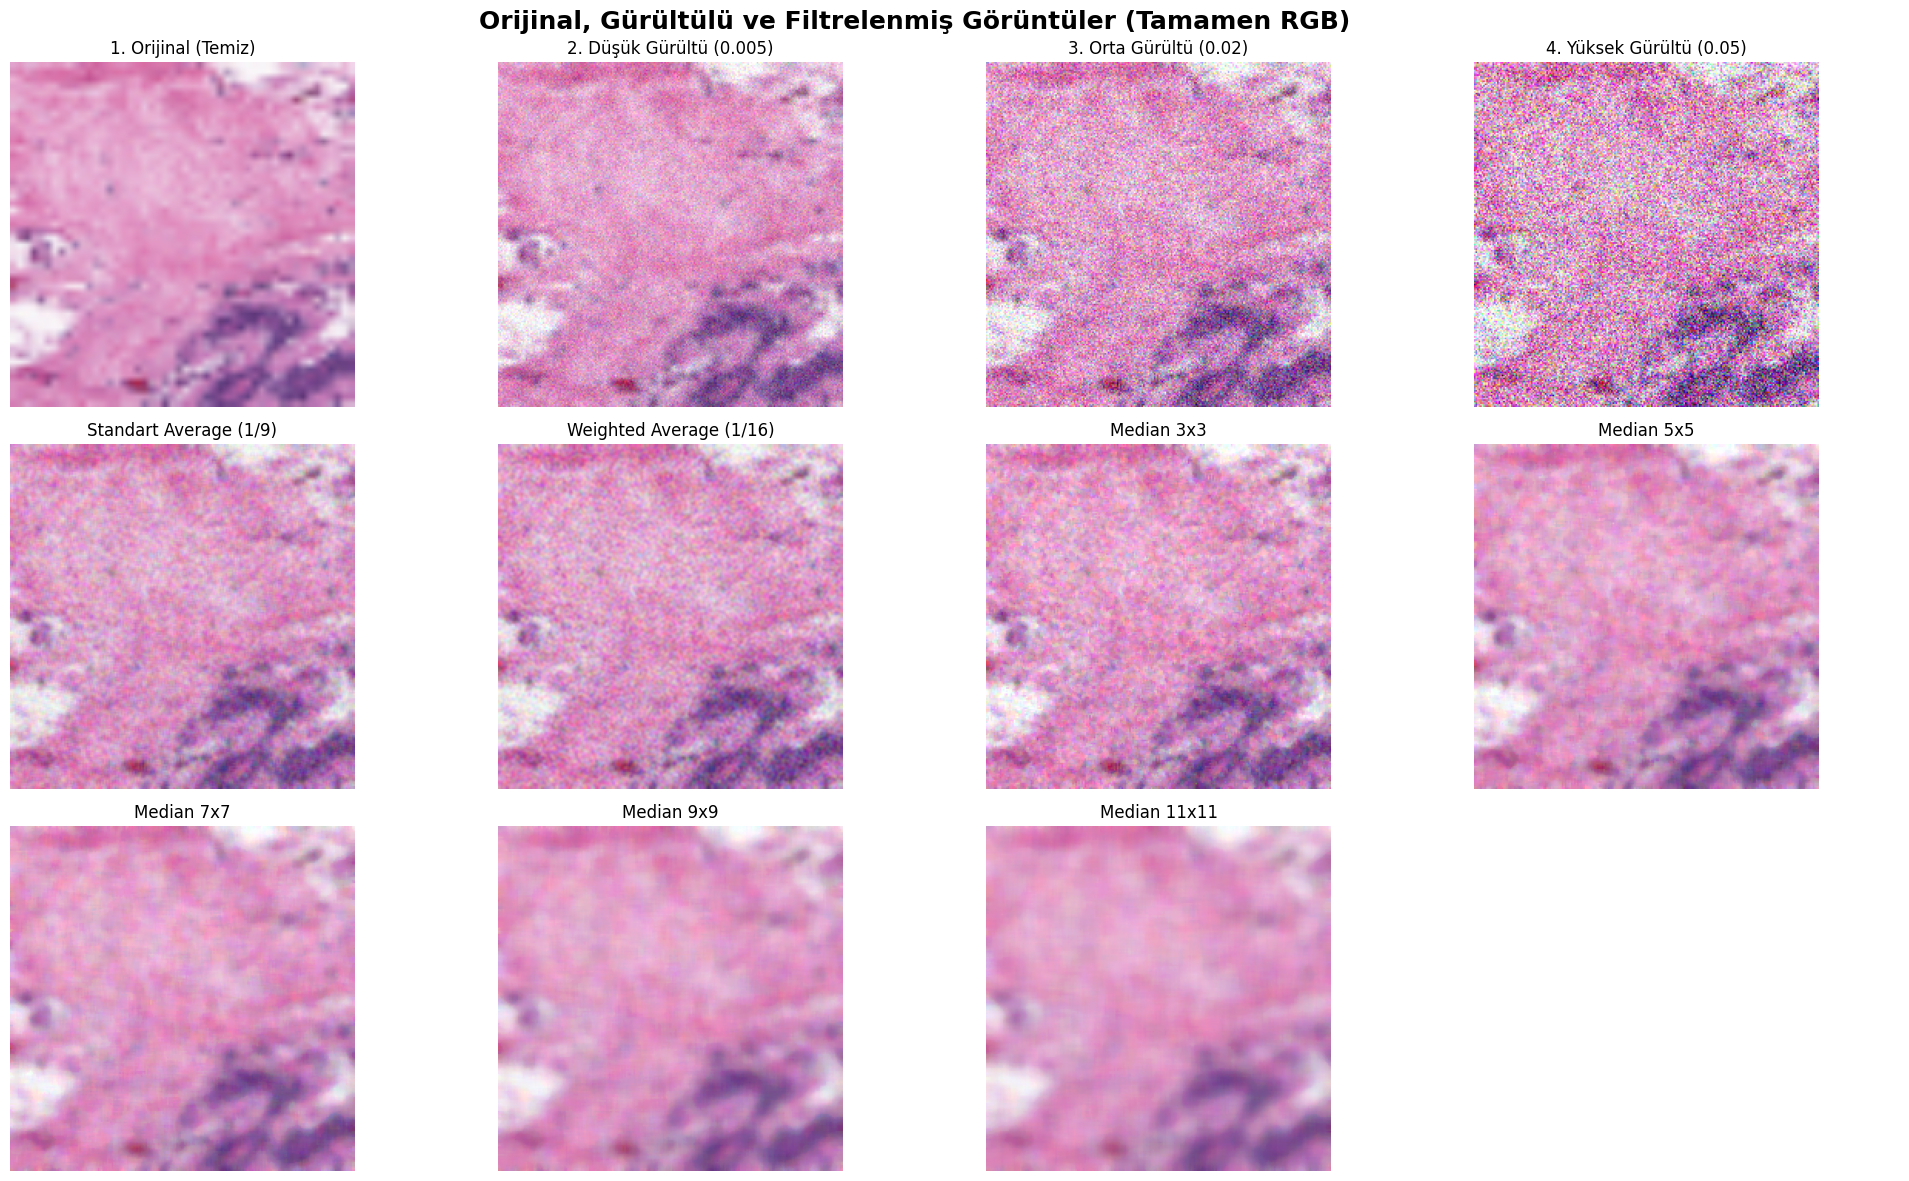

In [4]:
import matplotlib.pyplot as plt


sample_path = image_paths[0] 
img_clean = cv2.imread(sample_path)
img_clean = cv2.cvtColor(img_clean, cv2.COLOR_BGR2RGB)
img_clean = cv2.resize(img_clean, (224, 224)).astype(np.float32) / 255.0


img_low = add_noise(img_clean, 0.005)
img_med = add_noise(img_clean, 0.02)
img_high = add_noise(img_clean, 0.05)


filters_med = apply_filters(img_med)


fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle("Orijinal, Gürültülü ve Filtrelenmiş Görüntüler (Tamamen RGB)", fontsize=18, fontweight='bold')


axes[0, 0].imshow(img_clean); axes[0, 0].set_title("1. Orijinal (Temiz)")
axes[0, 1].imshow(img_low); axes[0, 1].set_title("2. Düşük Gürültü (0.005)")
axes[0, 2].imshow(img_med); axes[0, 2].set_title("3. Orta Gürültü (0.02)")
axes[0, 3].imshow(img_high); axes[0, 3].set_title("4. Yüksek Gürültü (0.05)")


axes[1, 0].imshow(filters_med["Standart average filter"]); axes[1, 0].set_title("Standart Average (1/9)")
axes[1, 1].imshow(filters_med["Weighted average filter"]); axes[1, 1].set_title("Weighted Average (1/16)")
axes[1, 2].imshow(filters_med["Median (3x3)"]); axes[1, 2].set_title("Median 3x3")
axes[1, 3].imshow(filters_med["Median (5x5)"]); axes[1, 3].set_title("Median 5x5")


axes[2, 0].imshow(filters_med["Median (7x7)"]); axes[2, 0].set_title("Median 7x7")
axes[2, 1].imshow(filters_med["Median (9x9)"]); axes[2, 1].set_title("Median 9x9")
axes[2, 2].imshow(filters_med["Median (11x11)"]); axes[2, 2].set_title("Median 11x11")
axes[2, 3].axis('off') # Son kutu boş kalsın

for ax in axes.flatten():
    ax.axis('off')

plt.tight_layout()
plt.show()